# Infraslow Phase vs. U-Sleep Sleep-Stage Probability

Visualizes the relationship between the infraslow (ISFS) phase (see
`demo_plot_and_compared_sigma.ipynb` Section 5.2, whose phase-extraction logic and 8-bin
phase convention this notebook reuses unmodified) and U-Sleep sleep-stage probabilities.

Group figure (Section 4-5): the average U-Sleep stage probability across the 8 ISFS phase
bins, computed subject-balanced (each subject's own per-bin mean first, then mean +/- SEM
across subjects -- never pooling raw per-sample probabilities across subjects) and
**separately per state** (N2, N3) -- each state has its own subject-inclusion set and its
own group curve/figure, never pooled together.

**Assumptions** (see this notebook's own plan, `docs/superpowers/plans/2026-08-20-phase-prob-stages.md`,
for how each was checked on real Sherlock data):
* U-Sleep hypnodensity `.npy` columns are in `Wake, N1, N2, N3, REM` order (matches
  `infraslow.io.hypnodensity`'s existing CSV convention; not independently verifiable from
  the `.npy` files themselves).
* A subject's U-Sleep hypnodensity and `temporal_ISFS`/`envelope` `t_env` share the same
  zero point (recording start) -- **assumed, not checked**: Section 2 no longer verifies
  the two recordings' lengths agree (the earlier duration-mismatch tolerance check was
  removed), so a subject/channel where they've drifted apart would silently misalign
  hypnodensity probabilities against ISFS phase rather than being excluded.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import yasa

from infraslow.pipeline import io as pio
from infraslow.pipeline import phase as pph
from infraslow.io import usleep_hypnodensity as uh
from infraslow.constants import (
    DEFAULT_MIN_BOUT_SEC,
    DEFAULT_USLEEP_HYPNODENSITY_DIR,
    USLEEP_STAGE_ORDER,
)
from infraslow.stat import state_comparison as stc

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE = '#5b2a86', '#c9b3e6'
ORANGE, LORANGE = '#d2691e', '#f2c14e'
COLORS = {"N2": (PURPLE, LPURPLE), "N3": (ORANGE, LORANGE)}

DATA_DIR = Path("/scratch/users/chaisaen/usleep_dryrun_v2/data")
USLEEP_DIR = DEFAULT_USLEEP_HYPNODENSITY_DIR
CHANNEL = "C3"
STATES = ("N2", "N3")

# Mirrors infraslow.pipeline.pipeline._EVENT_SPECS's "spindle"/"sw" artifact-pathway
# switch (band + bouts key + bouts loader + summary loader + peak column) -- duplicated
# here rather than importing infraslow.pipeline.pipeline, since that module transitively
# imports infraslow.pipeline.figures, which calls matplotlib.use("Agg") at import time and
# would silently break this notebook's inline plotting (see demo_plot_and_compared_sigma.ipynb's
# own comment on the same issue).
_EVENT_SPECS = {
    "spindle": dict(band="sigma", bouts_key="spindle", event_label="spindles",
                     load_bouts=pio.load_stage_bouts, load_summary=pio.load_spindle_summary,
                     peak_col="Peak"),
    "sw": dict(band="delta", bouts_key="sw", event_label="slow waves",
               load_bouts=pio.load_stage_sw_bouts, load_summary=pio.load_sw_summary,
               peak_col="NegPeak"),
}
# EVENT selects which artifact pathway drives Section 4.1's phase-bin distribution (and
# the band Section 2/4.2's ISFS phase itself is built from): "spindle" (default) pairs
# sigma-band ISFS with spindle_bouts.npz["spindle"]/spindle_yasa.csv["Peak"]; "sw" is the
# delta-band/slow-wave analog, pairing delta-band ISFS with sw_bouts.npz["sw"]/
# sw_yasa.csv["NegPeak"]. BAND is derived from EVENT (not set independently) so the two
# can never drift out of sync -- change EVENT alone to switch the whole notebook to "sw".
EVENT = "spindle"
BAND = _EVENT_SPECS[EVENT]["band"]
EVENT_LABEL = _EVENT_SPECS[EVENT]["event_label"]

# N_SUBJECTS caps how many *usable* subjects (Section 3) feed the group-level phase-locked
# curve (Section 4-5); usleep_dryrun_v2/data holds exactly 100 subjects (a preprocessing.py
# dry run), so 100 here just means "use every subject in the dry run".
N_SUBJECTS = 100
# Must match whatever --hypno-epoch-sec preprocessing.py was run with -- selects which
# <stage>/<N>s/ directory each subject's bout/event artifacts are read from (see
# infraslow.pipeline.io.epoch_dirname). usleep_dryrun_v2 was written with the default, 3s.
HYPNO_EPOCH_SEC = 3.0
# N_PHASE_POINTS: resolution of Section 4's group phase-locked curve -- 50 equal-
# width bins spanning the continuous ISFS phase (-pi, pi] (pph.continuous_phase_samples).
N_PHASE_POINTS = 50

## 2. Per-Subject Loader

Loads and aligns one subject's U-Sleep hypnodensity with its whole-recording ISFS phase
time series, or raises with a short, categorized reason (caught by the cohort-discovery
loop in Section 3). Uses `bouts["all"]` (every consecutive N2/N3 bout, not just
spindle-containing ones -- broader than `demo_plot_and_compared_sigma.ipynb`'s spectral
analysis, which specifically needs spindle-containing bouts) so the phase curve covers as
much of the night's N2/N3 structure as possible, applying the same
`DEFAULT_MIN_BOUT_SEC` defensive length filter `pipeline.pipeline.run_subject_state_channel`
applies.

In [2]:
def load_subject(data_dir: Path, usleep_dir: str, subject_id: str, channel: str,
                  states=STATES, band=BAND, *,
                  min_bout_sec: float = DEFAULT_MIN_BOUT_SEC,
                  hypno_epoch_sec: float = HYPNO_EPOCH_SEC) -> dict:
    """Load and align one subject's U-Sleep hypnodensity with its infraslow phase time
    series, or raise with a short, categorized reason.

    Returns a dict with keys `t_hyp`, `probs` (1-s hypnodensity), `phase` (this subject's
    whole-recording phase series, pooled across every state in `states` -- N2 and N3
    bouts are time-disjoint by construction, so concatenating and re-sorting is safe;
    carries both the discrete 1-8 `phase_bin`/`phase_angle` and the continuous
    `phase_continuous` (Section 4's 50-point group curve) built from the same bouts), and
    `bouts_by_state` (each state's filtered `(n, 2)` bout array).

    Raises:
        FileNotFoundError: missing U-Sleep hypnodensity, or missing temporal_ISFS/bouts
            artifacts.
        ValueError: no usable bouts.
    """
    subject_dir = Path(data_dir) / subject_id
    t_hyp, probs = uh.load_usleep_hypnodensity(subject_id, channel, base_dir=usleep_dir)
    t_env, filtered = pio.load_temporal_isfs(subject_dir, channel, band)

    bouts_by_state = {}
    phase_parts = []
    for state in states:
        bouts = pio.load_stage_bouts(subject_dir, channel, state, hypno_epoch_sec=hypno_epoch_sec)["all"]
        if bouts.shape[0]:
            durations = bouts[:, 1] - bouts[:, 0]
            bouts = bouts[durations >= min_bout_sec]
        bouts_by_state[state] = bouts
        if bouts.shape[0]:
            series = pph.build_subject_phase_timeseries(t_env, filtered, bouts)
            if series["t"].size:
                # Same bouts, same per-bout slicing/standardization as `series` above --
                # `continuous["t"]` is guaranteed elementwise-identical to `series["t"]`,
                # so the continuous phase can be attached as a plain column, no merge.
                continuous = pph.build_subject_continuous_phase_timeseries(t_env, filtered, bouts)
                series["phase_continuous"] = continuous["phase_angle"]
                phase_parts.append(pd.DataFrame(series).assign(state=state))

    if not phase_parts:
        raise ValueError(f"no usable {'/'.join(states)} bouts (>= {min_bout_sec}s) for this subject")

    phase = pd.concat(phase_parts, ignore_index=True).sort_values("t", kind="stable").reset_index(drop=True)
    return dict(t_hyp=t_hyp, probs=probs, phase=phase, bouts_by_state=bouts_by_state)

## 3. Cohort Discovery

Scans `pio.discover_subjects(DATA_DIR)` (sorted by id), keeping the first `N_SUBJECTS`
subjects `load_subject` succeeds on; every failure is caught and its exact message kept
for the exclusion report below (Section 3.1) rather than crashing the scan.

In [3]:
EXCLUSION_REASONS: dict[str, str] = {}
included: dict[str, dict] = {}
n_scanned = 0
verbose = True

for subject_id in pio.discover_subjects(DATA_DIR):
    if N_SUBJECTS is not None and len(included) >= N_SUBJECTS:
        break
    n_scanned += 1
    try:
        included[subject_id] = load_subject(DATA_DIR, USLEEP_DIR, subject_id, CHANNEL)
        if verbose:
            print(f"[{n_scanned}] {subject_id}: included -- {len(included)}/{N_SUBJECTS or '?'} so far")
    except (FileNotFoundError, ValueError, OSError) as exc:
        EXCLUSION_REASONS[subject_id] = str(exc)
        if verbose:
            print(f"[{n_scanned}] {subject_id}: excluded -- {exc}")

SUBJECT_IDS = list(included)
print(f"\nScanned {n_scanned} subject(s); included {len(SUBJECT_IDS)}, excluded {len(EXCLUSION_REASONS)}.")
assert SUBJECT_IDS, "no usable subjects found -- check DATA_DIR/USLEEP_DIR and CHANNEL"


[1] 317497: included -- 1/100 so far
[2] 317947: included -- 2/100 so far
[3] 318517: included -- 3/100 so far
[4] 318562: included -- 4/100 so far
[5] 318619: included -- 5/100 so far
[6] 318658: included -- 6/100 so far
[7] 318661: included -- 7/100 so far
[8] 318667: included -- 8/100 so far
[9] 318668: included -- 9/100 so far
[10] 318679: included -- 10/100 so far
[11] 320749: included -- 11/100 so far
[12] 320750: included -- 12/100 so far
[13] 320753: included -- 13/100 so far
[14] 320756: included -- 14/100 so far
[15] 320757: included -- 15/100 so far
[16] 320758: included -- 16/100 so far
[17] 320759: included -- 17/100 so far
[18] 320761: excluded -- no usable N2/N3 bouts (>= 200.0s) for this subject
[19] 320765: excluded -- no usable N2/N3 bouts (>= 200.0s) for this subject
[20] 320774: included -- 18/100 so far
[21] 322576: included -- 19/100 so far
[22] 322584: included -- 20/100 so far
[23] 322586: included -- 21/100 so far
[24] 322587: included -- 22/100 so far
[25] 322

### 3.1 Exclusion Report

In [4]:
def _categorize(reason: str) -> str:
    if "No U-Sleep hypnodensity directory" in reason:
        return "missing_usleep_subject_dir"
    if "No U-Sleep hypnodensity file for channel" in reason:
        return "missing_usleep_channel_file"
    if "temporal_ISFS" in reason:
        return "missing_temporal_isfs"
    if "bouts.npz" in reason:
        return "missing_bouts_file"
    if "no usable" in reason:
        return "no_usable_bouts"
    return "other"

exclusion_df = pd.DataFrame(
    [{"subject_id": sid, "reason_category": _categorize(reason), "detail": reason}
     for sid, reason in EXCLUSION_REASONS.items()]
)
print(f"Included: {len(SUBJECT_IDS)} / {n_scanned} scanned")
if len(exclusion_df):
    print("\nExcluded, by reason:")
    print(exclusion_df["reason_category"].value_counts().to_string())
else:
    print("No exclusions.")

Included: 85 / 100 scanned

Excluded, by reason:
reason_category
no_usable_bouts    15


## 4. Group-Level (Subject-Balanced) Average Hypnodensity Across Continuous ISFS Phase, Per State

### 4.1 Event Phase-Bin Distribution

Per subject/state: the % of `EVENT`s (spindles by default; slow waves if `EVENT="sw"`)
falling in each of the 8 discrete ISFS phase bins (`phase_bin_rates`) -- the same
`pph.build_bout_phase_data` + `pph.compute_subject_phase_features` pathway
`infraslow.pipeline.pipeline.run_subject_state_channel`'s `event`-selected branch uses
(`_EVENT_SPECS`, Section 1), and the exact figure `demo_plot_and_compared_sigma.ipynb`
Section 5.2 plots for `EVENT="spindle"`. Computed directly here (loading only the
event-containing bouts, temporal ISFS, and event summary for that one subject/state)
rather than via `run_subject_state_channel`, since only `phase_bin_rates` is needed --
its spectrum/bi-Gaussian fit is not.

A subject/state is excluded from this metric only (not from the rest of the notebook) if it
has no `EVENT`-containing bout >= `DEFAULT_MIN_BOUT_SEC`, or zero in-cycle events
(`phase_bin_rates` summing to 0) -- the same exclusion rule
`demo_plot_and_compared_sigma.ipynb`'s `_is_usable` applies.

Computed **first**, ahead of Section 4.2's continuous hypnodensity curve: since the figure
at the end of this section only ever uses subjects usable for *both* metrics, Section 4.2
restricts its own (more expensive) per-subject computation to this section's usable subject
set instead of running on every subject in `SUBJECT_IDS` and discarding the extra work.

In [5]:
def subject_event_phase_bin_rates(data_dir: Path, subject_id: str, channel: str, state: str, *,
                                   event: str = EVENT, min_bout_sec: float = DEFAULT_MIN_BOUT_SEC,
                                   hypno_epoch_sec: float = HYPNO_EPOCH_SEC):
    """This subject/state's `phase_bin_rates` (% of `event`s in each of the 8 discrete
    ISFS phase bins), or `None` if there are no usable `event`-containing bouts. Mirrors
    `infraslow.pipeline.pipeline.run_subject_state_channel`'s `event`-selected phase
    pathway exactly (same `_EVENT_SPECS` switch, same bout-length filter, same
    `pph.build_bout_phase_data` + `pph.compute_subject_phase_features` calls), skipping
    the spectrum/bi-Gaussian fit that pathway also computes but this figure does not
    need."""
    spec = _EVENT_SPECS[event]
    subject_dir = Path(data_dir) / subject_id
    bouts = spec["load_bouts"](subject_dir, channel, state, hypno_epoch_sec=hypno_epoch_sec)[spec["bouts_key"]]
    if bouts.shape[0]:
        durations = bouts[:, 1] - bouts[:, 0]
        bouts = bouts[durations >= min_bout_sec]
    if bouts.shape[0] == 0:
        return None

    t_env, filtered = pio.load_temporal_isfs(subject_dir, channel, spec["band"])
    event_summary = spec["load_summary"](subject_dir, channel, state, hypno_epoch_sec=hypno_epoch_sec)
    peak_col = spec["peak_col"]
    event_times = event_summary[peak_col].to_numpy() if peak_col in event_summary.columns else np.empty(0)

    bouts_data = pph.build_bout_phase_data(t_env, filtered, bouts, event_times)
    return pph.compute_subject_phase_features(bouts_data)


bin_centers = pph.bin_center_angle(np.arange(1, 9))
# {state: {subject_id: [8] phase_bin_rates}} -- per-subject rates only, not yet averaged
# (Section 4.3 does that). Section 4.2's continuous-curve loop is restricted to this
# section's own per-state subject set, computed first on purpose (see this section's
# markdown).
subject_rates_by_state: dict[str, dict[str, list]] = {}

for state in STATES:
    subject_rates = {}
    excluded = 0
    for sid in SUBJECT_IDS:
        try:
            feats = subject_event_phase_bin_rates(DATA_DIR, sid, CHANNEL, state)
        except (FileNotFoundError, OSError):
            # Event bouts existing (spindle_bouts.npz/sw_bouts.npz) does not guarantee the event
            # summary CSV is also readable -- same defensive stance as Section 3's
            # cohort-discovery loop.
            feats = None
        if feats is None or sum(feats["phase_bin_rates"]) <= 0:
            excluded += 1
            continue
        subject_rates[sid] = feats["phase_bin_rates"]

    print(f"{state}: {len(subject_rates)}/{len(SUBJECT_IDS)} subjects have a usable {EVENT} phase "
          f"distribution ({excluded} excluded -- no/too-few {EVENT}-containing bouts).")
    assert subject_rates, f"no subject has a usable {state} {EVENT} phase distribution"
    subject_rates_by_state[state] = subject_rates

N2: 64/85 subjects have a usable spindle phase distribution (21 excluded -- no/too-few spindle-containing bouts).
N3: 3/85 subjects have a usable spindle phase distribution (82 excluded -- no/too-few spindle-containing bouts).


### 4.2 Continuous Phase-Locked Hypnodensity

Per subject, per state: average the hypnodensity probability vector within each of
`N_PHASE_POINTS` (default 50) equal-width bins spanning the full continuous ISFS phase
range `(-pi, pi]` (`pph.continuous_phase_samples` -- linear interpolation *within* each of
`isfs_phase_bins`'s own 8 landmark segments, not a new phase definition), across every
in-cycle sample restricted to that one state's own bouts (one `(50, 5)` curve per subject
per state -- N2 and N3 are analyzed separately, never pooled).

Only computed for subjects already in Section 4.1's per-state usable set
(`subject_rates_by_state[state]`), not every subject in `SUBJECT_IDS` -- since the figure
at the end of this section only ever plots subjects usable for *both* metrics, computing
this curve for a subject Section 4.1 already excluded would be wasted computation (and the
discarded `(50, 5)` array wasted memory). A subject missing any of the 50 bins for a given
state is dropped from that state's continuous-curve subject set only (not from the other
state, and not from the rest of the notebook).

In [6]:
def subject_phase_locked_probs_continuous(data: dict, *, state: str | None = None,
                                           n_points: int = N_PHASE_POINTS) -> np.ndarray:
    """This subject's own mean hypnodensity probability vector across `n_points` equal-
    width bins spanning the continuous ISFS phase `(-pi, pi]` -- (n_points, n_stages),
    NaN row for any bin with zero in-cycle samples. `state=None` pools every state in
    `STATES`; `state="N2"`/`"N3"` restricts to that one state's own bouts."""
    phase = data["phase"]
    if state is not None:
        phase = phase[phase["state"] == state]
    in_cycle = phase["phase_continuous"].notna()
    t_in = phase.loc[in_cycle, "t"].to_numpy()
    phase_in = phase.loc[in_cycle, "phase_continuous"].to_numpy()
    probs_at = uh.hypnodensity_probs_at_times(t_in, data["t_hyp"], data["probs"])

    edges = np.linspace(-np.pi, np.pi, n_points + 1)
    bin_idx = np.digitize(phase_in, edges[1:-1])  # 0 .. n_points-1

    out = np.full((n_points, len(USLEEP_STAGE_ORDER)), np.nan)
    for b in range(n_points):
        mask = bin_idx == b
        if mask.any():
            out[b] = probs_at[mask].mean(axis=0)
    return out


# {state: {subject_id: (N_PHASE_POINTS, n_stages) curve}} -- per-subject curves only, NOT
# yet averaged into a group curve (Section 4.3 does that). Only computed for subjects
# already usable in Section 4.1's `subject_rates_by_state[state]` (see this section's
# markdown for why) -- so this is always a subset of Section 4.1's subject set.
subject_curves_by_state: dict[str, dict[str, np.ndarray]] = {}

for state in STATES:
    subject_curves = {}
    for sid in sorted(subject_rates_by_state[state]):
        curve = subject_phase_locked_probs_continuous(included[sid], state=state)
        if not np.isnan(curve).any():
            subject_curves[sid] = curve

    print(f"{state}: {len(subject_curves)}/{len(subject_rates_by_state[state])} "
          f"{EVENT}-usable subjects also have samples in all {N_PHASE_POINTS} phase points.")
    assert subject_curves, (
        f"no subject has complete {N_PHASE_POINTS}-point {state} phase coverage -- try raising N_SUBJECTS"
    )
    subject_curves_by_state[state] = subject_curves

phase_edges = np.linspace(-np.pi, np.pi, N_PHASE_POINTS + 1)
phase_points = (phase_edges[:-1] + phase_edges[1:]) / 2

N2: 62/64 spindle-usable subjects also have samples in all 50 phase points.
N3: 3/3 spindle-usable subjects also have samples in all 50 phase points.


### 4.3 Group Averages

Section 4.2 only ever computes a continuous curve for subjects already in Section 4.1's
usable set, so `subject_curves_by_state[state]` is already a subset of
`subject_rates_by_state[state]` by construction -- unlike when both sections scanned
`SUBJECT_IDS` independently, no intersection is needed here anymore. `stc.mean_sem`
(unmodified) is applied to each metric's per-subject arrays, restricted to
`subject_curves_by_state[state]`'s own subject set, so the figure's two subplots always
share the same `n` per state.

In [7]:
group_mean_by_state: dict[str, np.ndarray] = {}
group_sem_by_state: dict[str, np.ndarray] = {}
n_complete_by_state: dict[str, int] = {}
phase_bin_rates_by_state: dict[str, np.ndarray] = {}
spindle_phase_mean_by_state: dict[str, tuple[np.ndarray, np.ndarray]] = {}
spindle_n_complete_by_state: dict[str, int] = {}

for state in STATES:
    # subject_curves_by_state[state] is already a subset of subject_rates_by_state[state]
    # (Section 4.2 only computed curves for subjects Section 4.1 already deemed usable),
    # so it *is* the common subject set -- no intersection needed.
    common_ids = sorted(subject_curves_by_state[state])
    print(f"{state}: {len(common_ids)} subjects usable for both Section 4.1 "
          f"({len(subject_rates_by_state[state])}) and Section 4.2 "
          f"({len(subject_curves_by_state[state])}) -- these feed both panels of the figure below.")

    group_stack = np.stack([subject_curves_by_state[state][sid] for sid in common_ids])
    group_mean, group_sem = stc.mean_sem(group_stack, axis=0)  # each (N_PHASE_POINTS, n_stages)
    group_mean_by_state[state] = group_mean
    group_sem_by_state[state] = group_sem
    n_complete_by_state[state] = len(common_ids)

    rates_stack = np.stack([subject_rates_by_state[state][sid] for sid in common_ids])
    phase_bin_rates_by_state[state] = rates_stack
    spindle_phase_mean_by_state[state] = stc.mean_sem(rates_stack)
    spindle_n_complete_by_state[state] = len(common_ids)

N2: 62 subjects usable for both Section 4.1 (64) and Section 4.2 (62) -- these feed both panels of the figure below.
N3: 3 subjects usable for both Section 4.1 (3) and Section 4.2 (3) -- these feed both panels of the figure below.


#### Figure: average U-Sleep stage probability across continuous ISFS phase (top, 50 points, `yasa.Hypnogram.plot_hypnodensity` -- same stacked style as `test.ipynb`) with the event phase-bin distribution (bottom, Section 4.1), per state -- both panels drawn from Section 4.3's common subject set, so `n` matches top to bottom

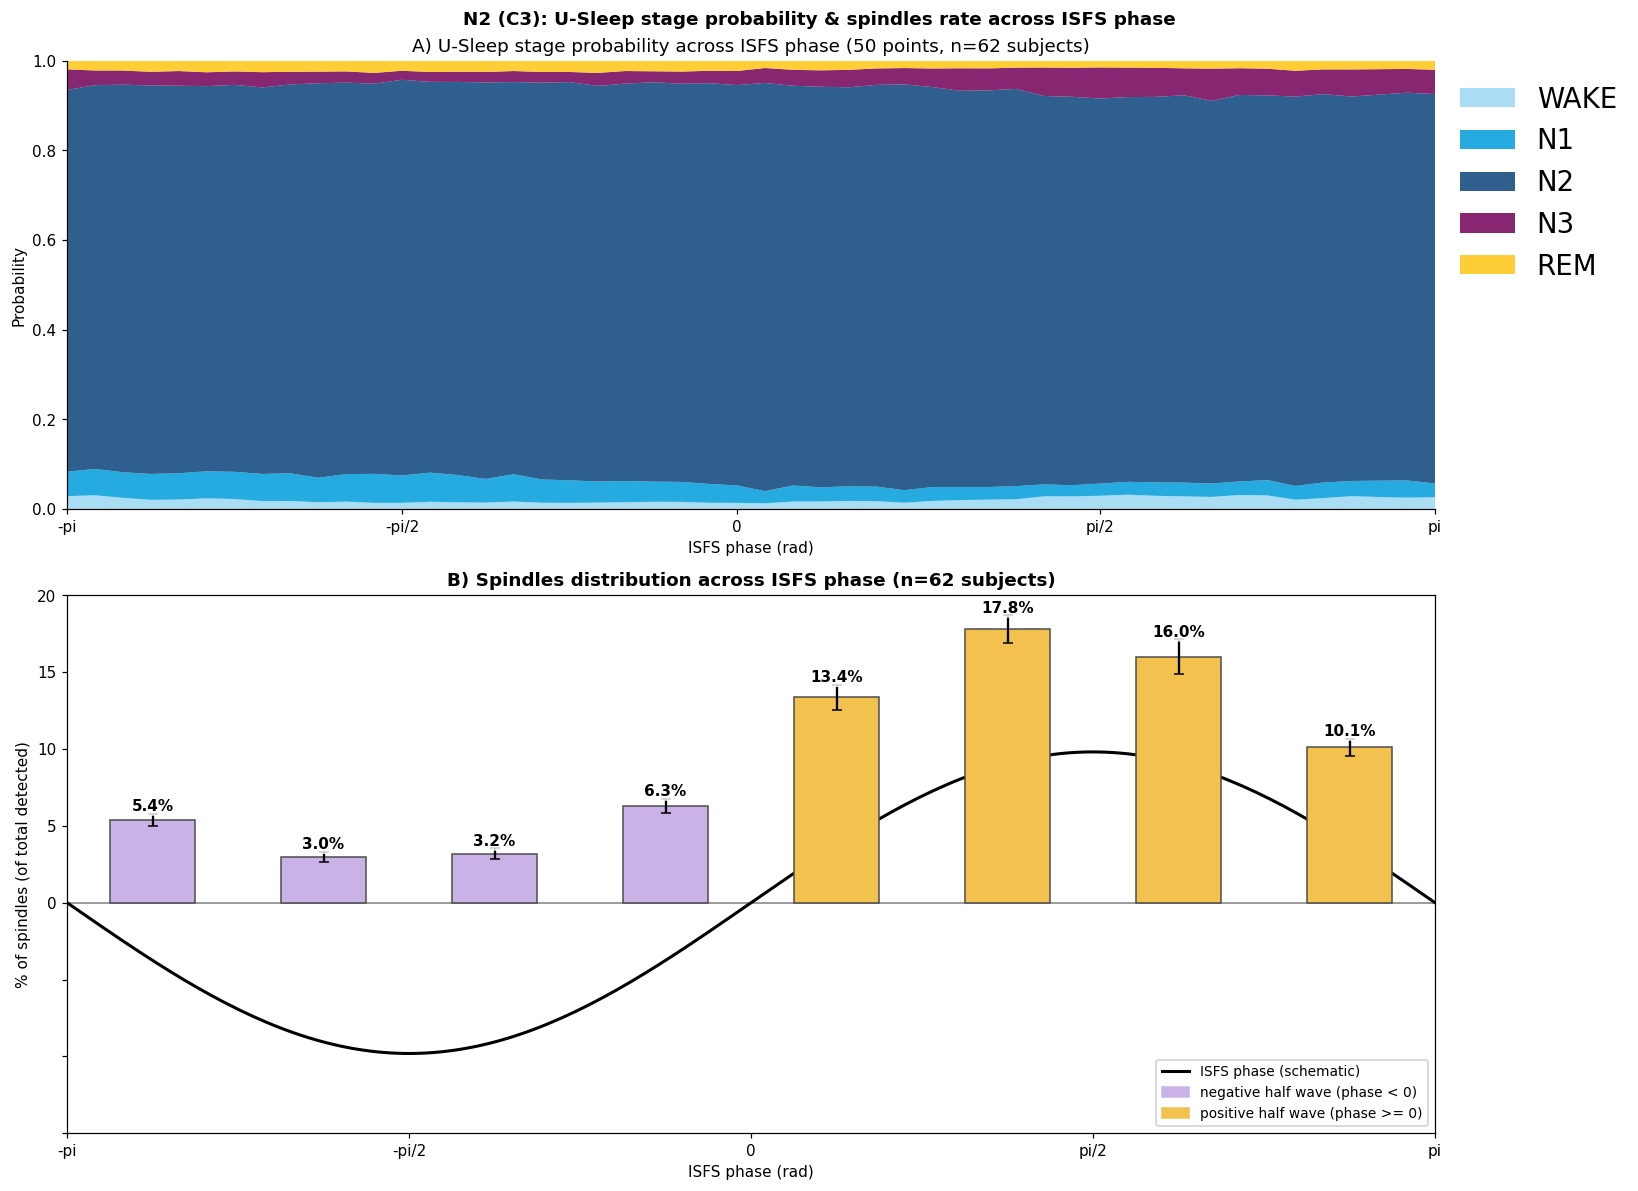

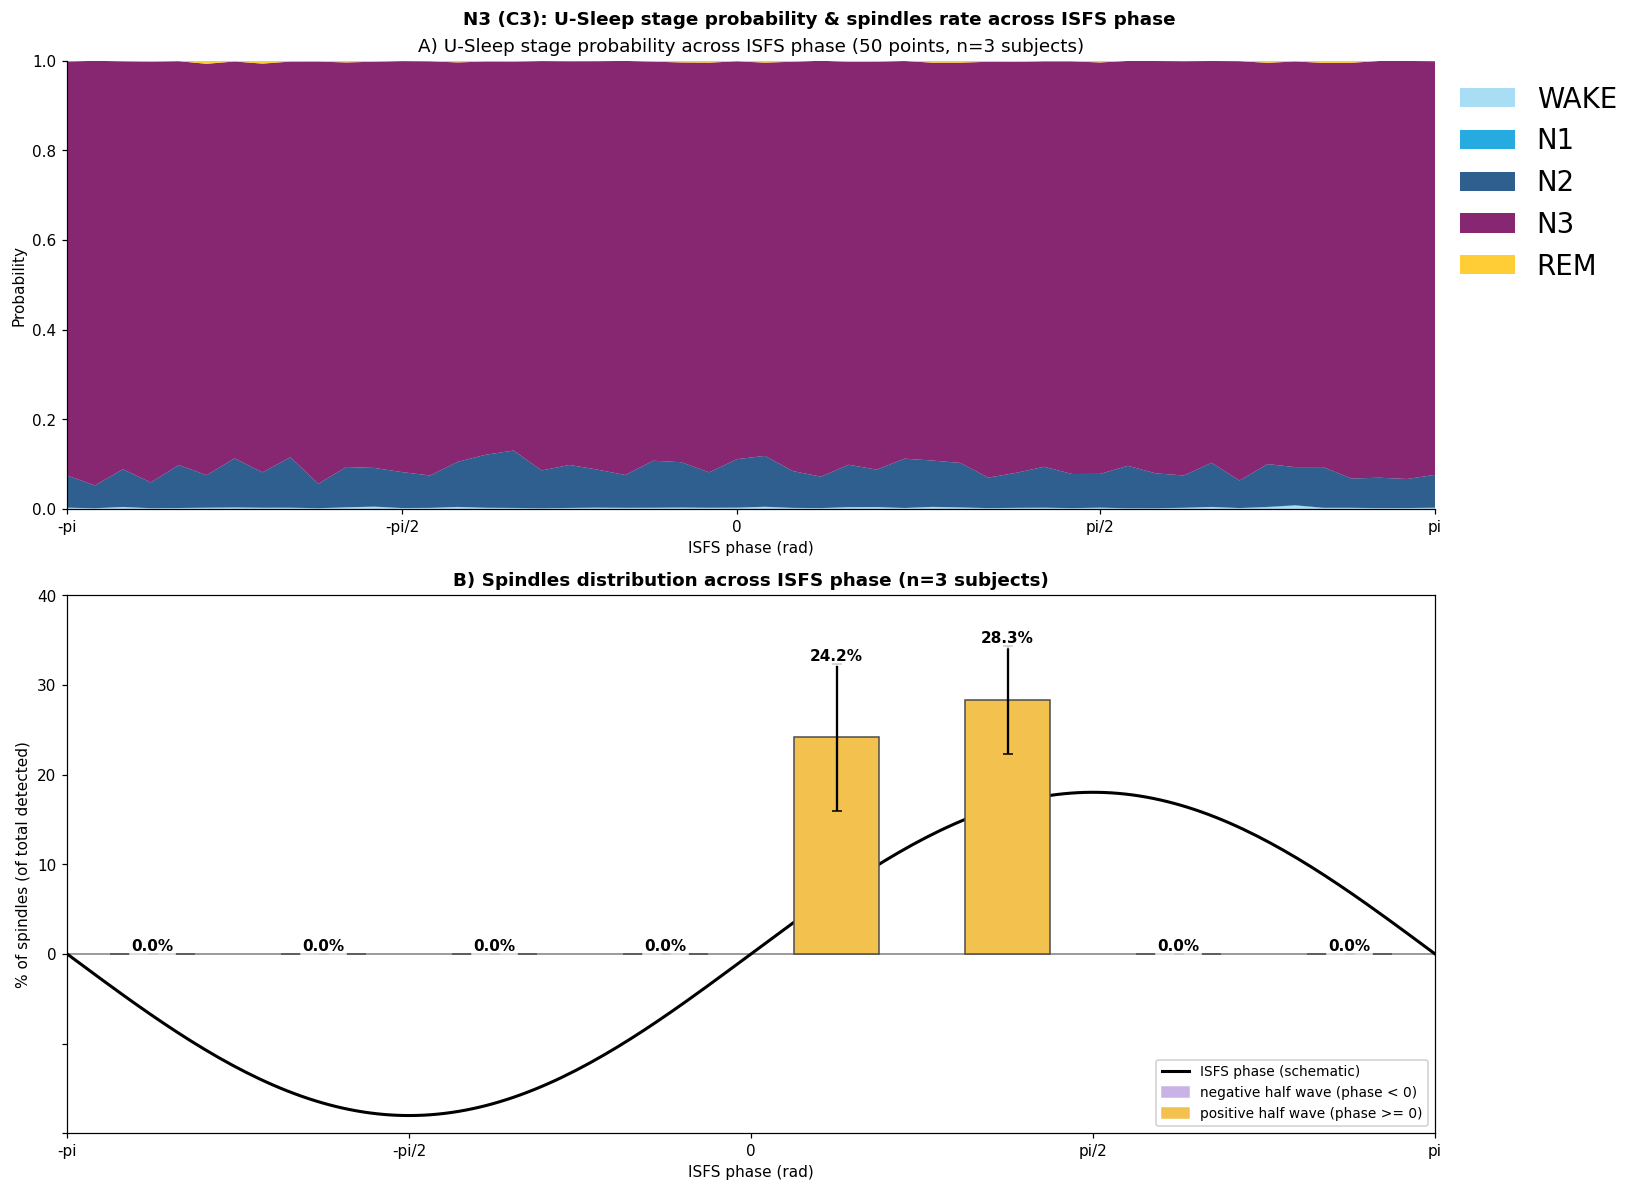

In [8]:
# Top subplot: build a yasa.Hypnogram out of each state's 50 phase-locked mean
# probabilities themselves (one "epoch" per phase point, `freq="1s"` a placeholder time
# unit -- there is no real time axis here, just N_PHASE_POINTS ordered points), then
# reuse `plot_hypnodensity` exactly as `test.ipynb` does, relabeling its (placeholder)
# time axis to phase afterward. Bottom subplot: that same state's Section 4.1 event
# phase-bin distribution, styled after `demo_infraslow_phase.ipynb` Figure 7 (bar-per-bin
# + schematic phase sine underneath, no "Not ISFS" 9th bar -- see Section 4.1's markdown),
# but plotted against the actual ISFS phase in radians `(-pi, pi]` (`pph.bin_center_angle`)
# instead of Figure 7's bare 1-8 bin index, so its x-axis matches the top panel's and
# every other phase axis in this notebook. One figure per state -- N2 and N3 are never
# overlaid/pooled in either subplot.
stage_cols = [s.upper() for s in USLEEP_STAGE_ORDER]
figs_group_by_state: dict[str, plt.Figure] = {}

for state in STATES:
    group_mean = group_mean_by_state[state]
    n_complete = n_complete_by_state[state]
    group_labels = [stage_cols[i] for i in np.argmax(group_mean, axis=1)]
    proba_df = pd.DataFrame(group_mean, columns=stage_cols)
    hyp_phase = yasa.Hypnogram(group_labels, n_stages=5, freq="1s", proba=proba_df)

    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(15, 11), gridspec_kw={"height_ratios": [1, 1.2]})
    hyp_phase.plot_hypnodensity(ax=ax_top)

    # plot_hypnodensity's x is elapsed time in minutes (or hours past 90 min) built from
    # the Hypnogram's own `timedelta`/`duration` -- mirror that exact conversion so the
    # relabeled ticks land on the right placeholder-time position, then overwrite the
    # labels themselves with the phase point they actually represent.
    x_all = hyp_phase.timedelta.total_seconds() / 60
    if hyp_phase.duration > 90:
        x_all = x_all / 60
    tick_phases = np.array([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
    tick_idx = np.array([np.argmin(np.abs(phase_points - p)) for p in tick_phases])
    ax_top.set_xticks(x_all[tick_idx])
    ax_top.set_xticklabels(["-pi", "-pi/2", "0", "pi/2", "pi"])
    ax_top.set_xlabel("ISFS phase (rad)")
    ax_top.set_title(f"A) U-Sleep stage probability across ISFS phase "
                      f"({N_PHASE_POINTS} points, n={n_complete} subjects)")

    # --- B) event distribution, demo_infraslow_phase.ipynb Figure 7 style, phase x-axis ---
    label_bbox = dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)
    bar_width = (2 * np.pi / 8) * 0.5
    bar_colors = [LPURPLE if c < 0 else LORANGE for c in bin_centers]
    mean_r, sem_r = spindle_phase_mean_by_state[state]
    ax_bottom.bar(bin_centers, mean_r, width=bar_width, yerr=sem_r, capsize=3,
                  color=bar_colors, edgecolor="0.3", zorder=2)
    for c, pct, err in zip(bin_centers, mean_r, sem_r):
        ax_bottom.text(c, pct + err, f"{pct:.1f}%", ha="center", va="bottom", fontsize=10,
                        fontweight="bold", bbox=label_bbox, zorder=6)

    # Schematic phase reference, same %-axis as the bars: one smooth sine period across
    # the real ISFS phase range `(-pi, pi]` -- since `x_smooth` here already *is* the
    # phase (unlike Figure 7's bin-index x, which needed remapping to an angle first).
    y0, y1 = ax_bottom.get_ylim()
    span = y1 - y0
    amp = 0.50 * span
    x_smooth = np.linspace(-np.pi, np.pi, 200)
    y_smooth = amp * np.sin(x_smooth)
    ax_bottom.plot(x_smooth, y_smooth, color="k", lw=2.0, ls="-", zorder=1, label="ISFS phase (schematic)")
    ax_bottom.axhline(0, color="0.5", lw=1.0, zorder=0)
    ax_bottom.set_ylim(min(y0, -amp - 0.03 * span), max(y1, amp + 0.03 * span))

    ax_bottom.set(xlim=(-np.pi, np.pi),
                  xticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
                  xticklabels=["-pi", "-pi/2", "0", "pi/2", "pi"],
                  xlabel="ISFS phase (rad)", ylabel=f"% of {EVENT_LABEL} (of total detected)")
    ax_bottom.set_title(f"B) {EVENT_LABEL.capitalize()} distribution across ISFS phase "
                         f"(n={spindle_n_complete_by_state[state]} subjects)", fontsize=12, fontweight="bold")
    ax_bottom.tick_params(labelsize=10)

    # Negative y-tick labels are meaningless (the phase curve is schematic, not real %)
    # -- blank them, keeping 0 and the positive (real, % of events) ticks.
    yticks = ax_bottom.get_yticks()
    ax_bottom.set_yticks(yticks)
    ax_bottom.set_yticklabels([f"{t:g}" if t >= 0 else "" for t in yticks])

    ax_bottom.legend(handles=ax_bottom.get_legend_handles_labels()[0] + [
        Patch(color=LPURPLE, label="negative half wave (phase < 0)"),
        Patch(color=LORANGE, label="positive half wave (phase >= 0)")],
        loc="lower right", frameon=True, framealpha=0.9, fontsize=9)

    fig.suptitle(f"{state} ({CHANNEL}): U-Sleep stage probability & {EVENT_LABEL} rate across ISFS phase",
                 fontweight="bold")
    fig.tight_layout()
    figs_group_by_state[state] = fig

## 5. Summary

In [9]:
print("=== Subject inclusion summary ===")
print(f"Scanned:  {n_scanned}")
print(f"Included: {len(SUBJECT_IDS)}")
print(f"Excluded: {len(EXCLUSION_REASONS)}")
if len(exclusion_df):
    print("\nExclusion reasons:")
    for reason, count in exclusion_df["reason_category"].value_counts().items():
        print(f"  {reason}: {count}")
print(f"\nEVENT = {EVENT!r} ({EVENT_LABEL}, band={BAND!r}), HYPNO_EPOCH_SEC = {HYPNO_EPOCH_SEC}")

print(f"\nSection 4.1 ({EVENT} phase-bin distribution) usable/excluded, out of "
      f"{len(SUBJECT_IDS)} included subjects:")
for state in STATES:
    n_usable = len(subject_rates_by_state[state])
    print(f"  {state}: {n_usable} usable, {len(SUBJECT_IDS) - n_usable} excluded")

print(f"\nSection 4.2 (continuous phase-locked hypnodensity) usable/excluded, out of each "
      f"state's Section 4.1-usable subjects:")
for state in STATES:
    n_attempted = len(subject_rates_by_state[state])
    n_usable = len(subject_curves_by_state[state])
    print(f"  {state}: {n_usable} usable, {n_attempted - n_usable} excluded (of {n_attempted} attempted)")

print(f"\nSubjects contributing to each state's figure (Section 4.3's common subject set -- "
      f"usable for both Section 4.1's event distribution and Section 4.2's continuous curve):")
for state in STATES:
    assert n_complete_by_state[state] == spindle_n_complete_by_state[state]
    print(f"  {state}: {n_complete_by_state[state]}/{len(SUBJECT_IDS)}")

=== Subject inclusion summary ===
Scanned:  100
Included: 85
Excluded: 15

Exclusion reasons:
  no_usable_bouts: 15

EVENT = 'spindle' (spindles, band='sigma'), HYPNO_EPOCH_SEC = 3.0

Section 4.1 (spindle phase-bin distribution) usable/excluded, out of 85 included subjects:
  N2: 64 usable, 21 excluded
  N3: 3 usable, 82 excluded

Section 4.2 (continuous phase-locked hypnodensity) usable/excluded, out of each state's Section 4.1-usable subjects:
  N2: 62 usable, 2 excluded (of 64 attempted)
  N3: 3 usable, 0 excluded (of 3 attempted)

Subjects contributing to each state's figure (Section 4.3's common subject set -- usable for both Section 4.1's event distribution and Section 4.2's continuous curve):
  N2: 62/85
  N3: 3/85
